### Setup

In [61]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from vit_pytorch import ViT
import os
import csv
import torch.nn.functional as F

# ==== CONFIG ====
DATA_DIR = "/Users/jacobanderson/Documents/Spring 2025/CompE696/compe-696/OTB100"
BATCH_SIZE = 16
EPOCHS = 5
IMG_SIZE = 224
TRAIN_SPLIT = 0.9
LEARNING_RATE = 3e-4
CSV_LOG_PATH = "vit_test_predictions.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Transform

In [62]:
# ==== TRANSFORMS ====
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

### Load data

In [63]:
# ==== LOAD DATA ====
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = full_dataset.classes
train_len = int(TRAIN_SPLIT * len(full_dataset))
test_len = len(full_dataset) - train_len
train_set, test_set = random_split(full_dataset, [train_len, test_len])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)  # Batch size 1 for logging


### ViT Model

In [64]:
# ==== VIT MODEL ====
model = ViT(
    image_size=IMG_SIZE,
    patch_size=16,
    num_classes=len(class_names),
    dim=512,
    depth=6,
    heads=8,
    mlp_dim=1024,
    dropout=0.1,
    emb_dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), LEARNING_RATE)


### Training

In [65]:
# ==== TRAINING ====
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    print(f"[Epoch {epoch+1}] Loss: {total_loss:.4f}, Train Acc: {100 * correct / total:.2f}%")


[Epoch 1] Loss: 83.3242, Train Acc: 85.79%
[Epoch 2] Loss: 18.7006, Train Acc: 97.33%
[Epoch 3] Loss: 9.4560, Train Acc: 98.71%
[Epoch 4] Loss: 8.1905, Train Acc: 98.90%
[Epoch 5] Loss: 7.3519, Train Acc: 98.76%


### Testing

In [66]:
# ==== TESTING WITH LOGGING ====
model.eval()
correct = 0
total = 0

with open(CSV_LOG_PATH, mode='w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(["image_index", "true_label", "predicted_label", "confidence"])

    with torch.no_grad():
        for idx, (images, labels) in enumerate(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            top_probs, top_idxs = probs.max(1)
            predicted = top_idxs.item()
            confidence = top_probs.item()

            correct += (predicted == labels.item())
            total += 1

            csv_writer.writerow([
                idx,
                class_names[labels.item()],
                class_names[predicted],
                f"{confidence:.4f}"
            ])

print(f"🎯 Test Accuracy: {100 * correct / total:.2f}%")

🎯 Test Accuracy: 96.29%


### Generate Confusion Matrix

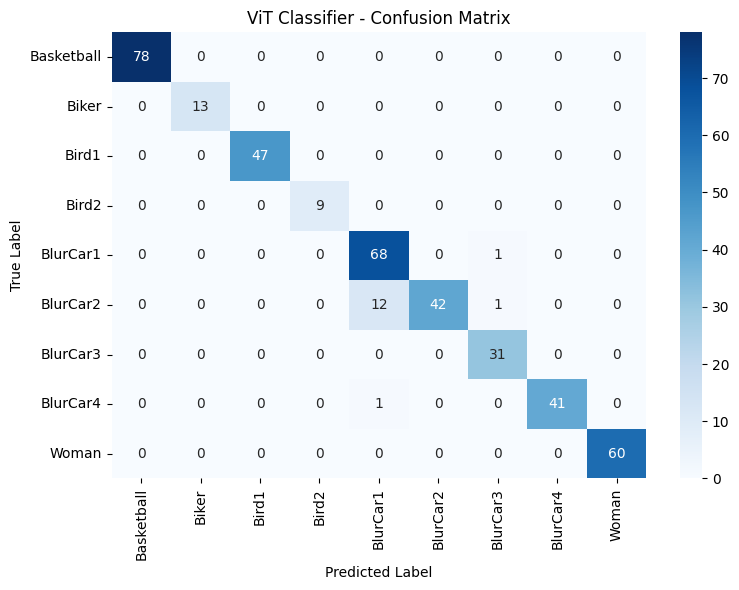

In [67]:
# Re-import necessary modules after code execution environment reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load CSV
csv_path = "vit_test_predictions.csv"
df = pd.read_csv(csv_path)

# Extract true and predicted labels
true_labels = df["true_label"]
pred_labels = df["predicted_label"]

# Compute confusion matrix
labels = sorted(df["true_label"].unique())
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ViT Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()


### Save model

In [68]:
torch.save(model.state_dict(), "vit_target_recognition.pth")
print("Model saved to vit_target_recognition.pth")

Model saved to vit_target_recognition.pth


### Object tracking: Prediction vs. Ground Truth

In [ ]:
import os
import cv2
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import re
from torchvision import transforms
from vit_pytorch import ViT
from torchvision.datasets import ImageFolder
from sklearn.metrics import jaccard_score
from matplotlib import pyplot as plt

# === CONFIG ===
DATASET_ROOT = "/Users/jacobanderson/Documents/Spring 2025/CompE696/compe-696/OTB100"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
SEARCH_RADIUS = 20  # pixels
STRIDE = 10
CSV_OUTPUT = "tracking_classification_output.csv"

# === Load ViT Model and Class Names ===
dataset = ImageFolder(DATASET_ROOT)
class_names = dataset.classes
model = ViT(
    image_size=IMG_SIZE,
    patch_size=16,
    num_classes=9,#len(class_names),
    dim=512,
    depth=6,
    heads=8,
    mlp_dim=1024,
    dropout=0.1,
    emb_dropout=0.1
).to(DEVICE)

state_dict = torch.load("vit_target_recognition.pth", map_location=DEVICE)
model.load_state_dict(state_dict, strict=False)
model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# === Utility ===
def classify_patch(img_patch):
    input_tensor = transform(img_patch).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        return class_names[pred_idx], probs[pred_idx].item()

def safe_iou(boxA, boxB):
    try:
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
        yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = boxA[2] * boxA[3]
        boxBArea = boxB[2] * boxB[3]
        return interArea / float(boxAArea + boxBArea - interArea)
    except Exception as e:
        print(f"Failed to compute IoU: {e} | GT: {boxA}, Pred: {boxB}")
        return 0.0

# === Process All Sequences ===
all_results = []

for seq_name in sorted(os.listdir(DATASET_ROOT)):
    seq_path = os.path.join(DATASET_ROOT, seq_name)
    gt_path = os.path.join(seq_path, "groundtruth_rect.txt")
    img_folder = os.path.join(seq_path, "img")
    if not os.path.exists(gt_path) or not os.path.isdir(img_folder):
        continue
      
    with open(gt_path, "r") as f:
        gt_boxes = [list(map(int, re.split(r"[\s,]+", line.strip()))) for line in f if line.strip()]

    frame_files = sorted(os.listdir(img_folder))
    predicted_boxes = []
    processed_frames = []
    iou_scores = []

    first_frame_path = os.path.join(img_folder, frame_files[0])
    first_frame = cv2.imread(first_frame_path)
    if first_frame is None:
        print(f"⚠️ Skipping sequence '{seq_name}' due to missing first frame.")
        continue
    x, y, w, h = gt_boxes[0]
    crop = first_frame[y:y+h, x:x+w]
    true_label, _ = classify_patch(crop)
    predicted_boxes.append([x, y, w, h])
    iou_scores.append(1.0)
    processed_frames.append(frame_files[0])

    for i in range(1, len(frame_files)):
        img_path = os.path.join(img_folder, frame_files[i])
        frame = cv2.imread(img_path)
        if frame is None:
            print(f"Skipping frame {frame_files[i]} (could not load)")
            continue

        prev_x, prev_y, prev_w, prev_h = predicted_boxes[-1]
        best_conf = -1
        best_box = None

        for dx in range(-SEARCH_RADIUS, SEARCH_RADIUS+1, STRIDE):
            for dy in range(-SEARCH_RADIUS, SEARCH_RADIUS+1, STRIDE):
                cx = max(0, prev_x + dx)
                cy = max(0, prev_y + dy)
                if cx+prev_w > frame.shape[1] or cy+prev_h > frame.shape[0]:
                    continue
                candidate = frame[cy:cy+prev_h, cx:cx+prev_w]
                pred_label, conf = classify_patch(candidate)
                if pred_label == true_label and conf > best_conf:
                    best_conf = conf
                    best_box = [cx, cy, prev_w, prev_h]

        if best_box is None:
            best_box = predicted_boxes[-1]

        predicted_boxes.append(best_box)
        iou = safe_iou(gt_boxes[i], best_box)
        iou_scores.append(iou)
        processed_frames.append(frame_files[i])

    valid_count = min(len(processed_frames), len(gt_boxes), len(predicted_boxes), len(iou_scores))
    print(f"Finished sequence: {seq_name} — {valid_count} frames processed")
    for i in range(valid_count):
        all_results.append({
            "sequence": seq_name,
            "frame": processed_frames[i],
            "gt_x": gt_boxes[i][0],
            "gt_y": gt_boxes[i][1],
            "gt_w": gt_boxes[i][2],
            "gt_h": gt_boxes[i][3],
            "pred_x": predicted_boxes[i][0],
            "pred_y": predicted_boxes[i][1],
            "pred_w": predicted_boxes[i][2],
            "pred_h": predicted_boxes[i][3],
            "iou": iou_scores[i]
        })

results_df = pd.DataFrame(all_results)
results_df.to_csv(CSV_OUTPUT, index=False)
print(f"Tracking complete for all sequences. Results saved to {CSV_OUTPUT}")
if 'iou' in results_df.columns and not results_df['iou'].empty:
    print(f"Overall Average IoU: {results_df['iou'].mean():.4f}")
else:
    print("No valid IoU values were recorded.")


✅ Finished sequence: Basketball — 725 frames processed
✅ Finished sequence: Biker — 142 frames processed
✅ Finished sequence: Bird1 — 408 frames processed
✅ Finished sequence: Bird2 — 99 frames processed
✅ Finished sequence: BlurCar1 — 742 frames processed
✅ Finished sequence: BlurCar2 — 585 frames processed
✅ Finished sequence: BlurCar3 — 357 frames processed
✅ Finished sequence: BlurCar4 — 380 frames processed
✅ Finished sequence: Woman — 597 frames processed
✅ Tracking complete for all sequences. Results saved to tracking_classification_output.csv
📊 Overall Average IoU: 0.1125


### Visualize the difference

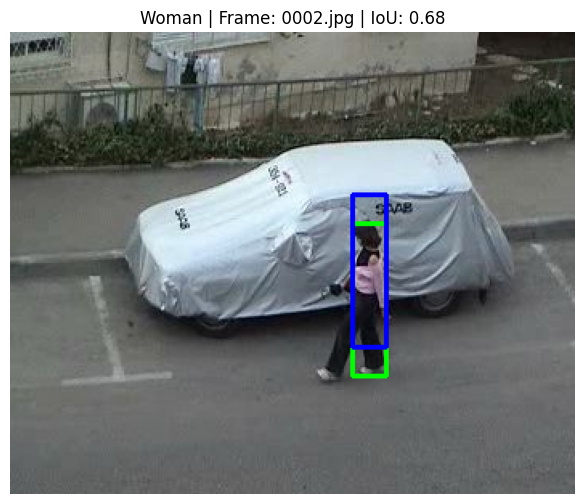

In [ ]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualize_prediction(folder_path, sequence_name, frame_name, csv_path="/Users/jacobanderson/Documents/Spring 2025/CompE696/compe-696/tracking_classification_output.csv"):
    # Load the tracking results CSV
    df = pd.read_csv(csv_path)

    # Look up the row for the specified sequence and frame
    match = df[(df["sequence"] == sequence_name) & (df["frame"] == frame_name)]
    if match.empty:
        print("No match found for the specified sequence and frame.")
        return

    row = match.iloc[0]

    # Construct full path to the image
    img_path = f"{folder_path}/{sequence_name}/img/{frame_name}"
    image = cv2.imread(img_path)

    if image is None:
        print(f"Could not load image at: {img_path}. Using placeholder.")
        image = 255 * np.ones((480, 640, 3), dtype=np.uint8)

    # Draw ground truth box (green)
    gt_x, gt_y, gt_w, gt_h = int(row["gt_x"]), int(row["gt_y"]), int(row["gt_w"]), int(row["gt_h"])
    cv2.rectangle(image, (gt_x, gt_y), (gt_x + gt_w, gt_y + gt_h), (0, 255, 0), 2)

    # Draw predicted box (red)
    pred_x, pred_y, pred_w, pred_h = int(row["pred_x"]), int(row["pred_y"]), int(row["pred_w"]), int(row["pred_h"])
    cv2.rectangle(image, (pred_x, pred_y), (pred_x + pred_w, pred_y + pred_h), (255, 0, 0), 2)

    # Show the image
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"{sequence_name} | Frame: {frame_name} | IoU: {row['iou']:.2f}")
    plt.axis('off')
    plt.show()

# Example usage (replace these with your actual input):
visualize_prediction(
    folder_path="/Users/jacobanderson/Documents/Spring 2025/CompE696/compe-696/OTB100",
    sequence_name="Woman",
    frame_name="0002.jpg"
)
